# Spam Email Detection using Naive Bayes

## Synent Technologies Internship - Task 8

### Objective
Detect spam emails using Natural Language Processing and Machine Learning techniques.

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- NLTK

### Tasks Performed
- Text preprocessing
- Exploratory Data Analysis
- NLP processing
- Feature extraction
- Machine Learning classification
- Spam detection
- Model evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv(
    "spam.csv",
    encoding='latin1'
)

## Dataset Preview

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## Selecting Important Columns

In [4]:
df = df[["v1", "v2"]]

## Renaming Columns

In [5]:
df.columns = [
    "label",
    "message"
]

## Dataset Shape

In [6]:
df.shape

(5572, 2)

## Dataset Information

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 541.4 KB


## Missing Values

In [9]:
df.isnull().sum()

label      0
message    0
dtype: int64

## Duplicate Records

In [10]:
df.duplicated().sum()

np.int64(403)

## Removing Duplicate Records

In [11]:
df = df.drop_duplicates()

## Spam vs Ham Distribution

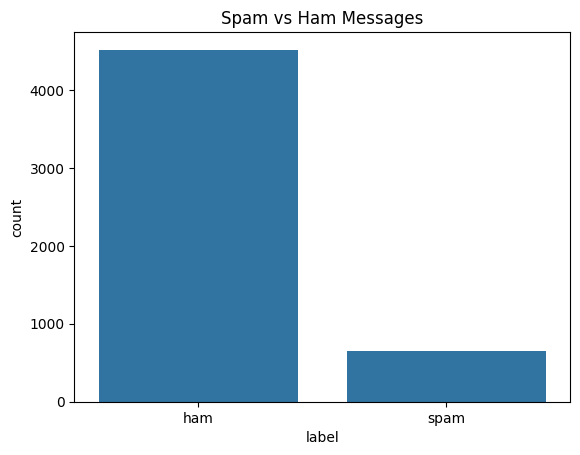

In [12]:
sns.countplot(
    x="label",
    data=df
)

plt.title(
    "Spam vs Ham Messages"
)

plt.show()

## Message Length Analysis

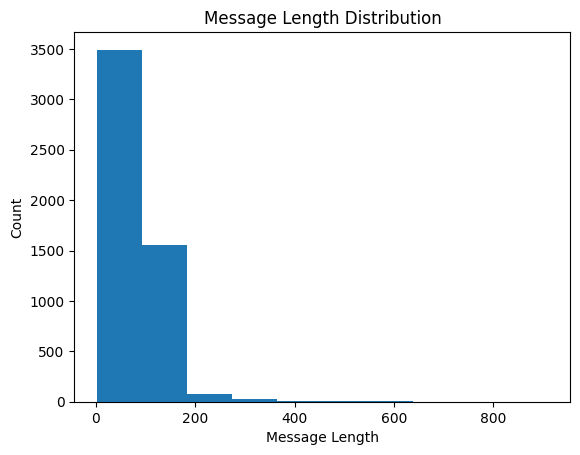

In [13]:
df["message_length"] = df[
    "message"
].apply(len)

plt.hist(df["message_length"])

plt.title(
    "Message Length Distribution"
)

plt.xlabel("Message Length")

plt.ylabel("Count")

plt.show()

## Spam vs Ham Message Length

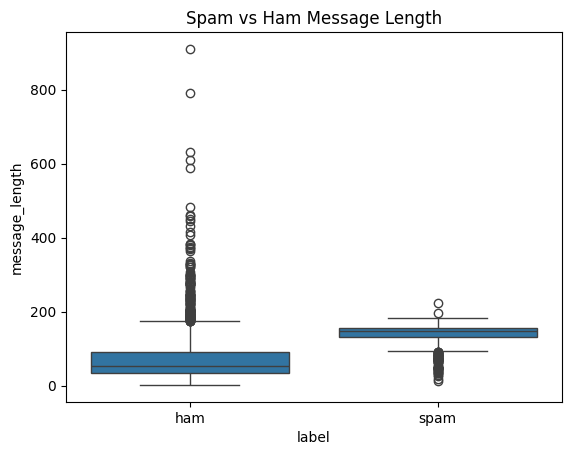

In [14]:
sns.boxplot(
    x="label",
    y="message_length",
    data=df
)

plt.title(
    "Spam vs Ham Message Length"
)

plt.show()

## Label Encoding

In [15]:
df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

## Feature Selection

In [16]:
X = df["message"]

y = df["label"]

## Train-Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Text Vectorization

In [18]:
vectorizer = CountVectorizer()

X_train_vectorized = vectorizer.fit_transform(
    X_train
)

X_test_vectorized = vectorizer.transform(
    X_test
)

## Training Naive Bayes Model

In [19]:
model = MultinomialNB()

model.fit(
    X_train_vectorized,
    y_train
)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


## Predictions

In [21]:
y_pred = model.predict(
    X_test_vectorized
)

## Model Accuracy

In [22]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    accuracy
)

Accuracy: 0.9854932301740812


## Confusion Matrix

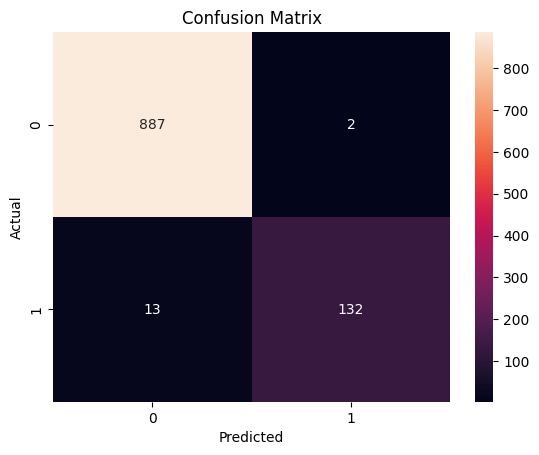

In [23]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Classification Report

In [24]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       889
           1       0.99      0.91      0.95       145

    accuracy                           0.99      1034
   macro avg       0.99      0.95      0.97      1034
weighted avg       0.99      0.99      0.99      1034



## Most Common Words

In [25]:
word_counts = vectorizer.get_feature_names_out()

print(
    word_counts[:50]
)

['00' '000' '000pes' '008704050406' '0089' '0121' '01223585236'
 '01223585334' '0125698789' '02' '0207' '02072069400' '02073162414'
 '02085076972' '021' '03' '04' '05' '050703' '0578' '06' '07'
 '07008009200' '07046744435' '07090201529' '07090298926' '07099833605'
 '07123456789' '0721072' '07732584351' '07734396839' '07742676969'
 '07753741225' '0776xxxxxxx' '07786200117' '077xxx' '078' '07808247860'
 '07808726822' '07815296484' '078498' '07880867867' '0789xxxxxxx'
 '07946746291' '07xxxxxxxxx' '08' '0800' '08000407165' '08000776320'
 '08000839402']


## Sample Predictions

In [27]:
sample_messages = [
    "Congratulations! You won a free iPhone",
    "Hey, are we meeting today?",
    "Claim your free reward now",
    "Can you send the assignment?"
]

sample_vectorized = vectorizer.transform(
    sample_messages
)

predictions = model.predict(
    sample_vectorized
)

for message, prediction in zip(
    sample_messages,
    predictions
):

    if prediction == 1:
        print(message, "-> Spam")

    else:
        print(message, "-> Ham")

Congratulations! You won a free iPhone -> Spam
Hey, are we meeting today? -> Ham
Claim your free reward now -> Spam
Can you send the assignment? -> Ham


## Top Spam Words

In [28]:
spam_messages = df[
    df["label"] == 1
]

spam_words = " ".join(
    spam_messages["message"]
)

print(spam_words[:1000])

Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, å£1.50 to rcv WINNER!! As a valued network customer you have been selected to receivea å£900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only. Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Update Co FREE on 08002986030 SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 4 info URGENT! You have won a 1 week FREE membership in our å£100,000 Prize Jackpot! Txt the word: CLAIM to No: 81010 T&C www.dbuk.net LCCLTD POBOX 4403LDNW1A7RW18 XXXMobileMovieClub: To use your credit, click the WAP link in the next txt message or c

# Key Insights

1. Spam messages often contain promotional or urgent words.

2. Spam messages are generally longer than ham messages.

3. Naive Bayes performs effectively for text classification.

4. Text vectorization converts messages into numerical features.

5. Machine Learning successfully classifies spam and ham messages.

6. NLP techniques help automate spam filtering systems.

# Final Conclusion

This project implemented a Spam Email Detection system using Natural Language Processing and the Naive Bayes Machine Learning algorithm.

The project included:
- Text preprocessing
- Feature extraction
- Machine Learning classification
- Prediction
- Model evaluation
- NLP analysis

The model successfully classified spam and ham messages and demonstrated practical NLP and Machine Learning skills.